[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duke-aipi-Han/aipi590-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** SHAP

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | Gold | Mean absolute TreeSHAP ranks `debt_ratio` first across the test set. | The ranking describes model reliance, not causality, and may include spurious correlations. |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | Gold | The local waterfall shows `zip_proxy=1` as the assigned case's largest positive contribution. | Contributions are relative to SHAP's baseline. |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | Gold | In the shortcut probe, marker attribution per pixel is about 18 times shape attribution, and the heatmap concentrates on the marker. | Strong attribution evidence, but marker removal would provide a direct causal test. |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | Gold | The SHAP dependence plot shows predicted risk increasing with `debt_ratio` and leveling off above roughly 0.6. | This is a model effect rather than a causal effect; the apparent plateau merits further investigation. |
| 5. Compare Two Predictions | Why were two cases classified differently? | Gold | Separate low/high waterfalls and their SHAP difference show debt ratio, late payments, and `zip_proxy` explain most of the gap. | The comparison uses a shared SHAP baseline and does not imply causality. |
| 6. Feature Interactions | Which tabular variables work together? | Gold | The ranked table and heatmap identify `debt_ratio` with late payments as strongest; `zip_proxy` also interacts with several features. | SHAP interaction strength is predictive, not causal. |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | Gold | Predicted-class GradientSHAP heatmaps across four cases emphasize the corner marker more than the shape. | Heatmaps use absolute attribution and depend on the background sample. |
| 8. Explain a Failure | Why did the model make this mistake? | Silver | Debt raises the failed case's score, but no late payments and `zip_proxy=0` pull it below 0.5. | SHAP explains this incorrect score, not the full reason the model generalized incorrectly. |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Silver | Tiny perturbations keep SHAP nearly unchanged but move probability from about 49.7% to 50.7%, flipping the hard label. | This supports local explanation stability, but cannot establish calibration, fairness, or safety. |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | Global SHAP shows a debt/proxy-driven tabular strategy, while image SHAP shows strong marker reliance across four cases. | The small image sample and attribution-only evidence limit the global conclusion. |


In [1]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6576
epoch 2: loss=0.2582
epoch 3: loss=0.0858
epoch 4: loss=0.0955
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.986
2,contrast_square,4,1,0,0,0.065
3,failure_case,6,0,1,1,0.980


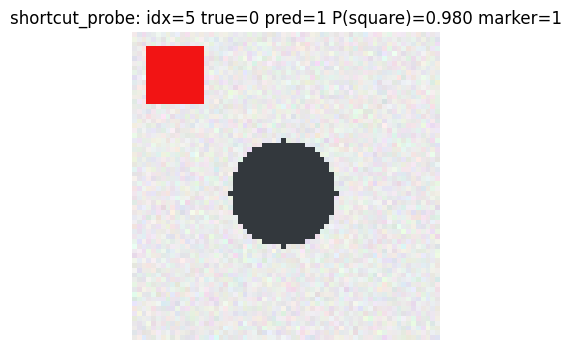

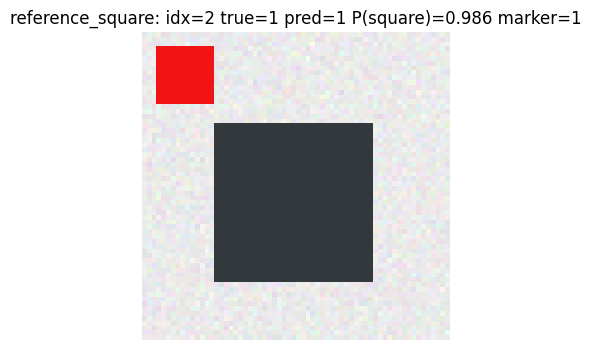

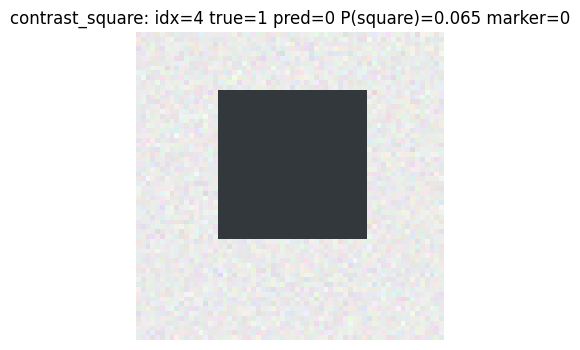

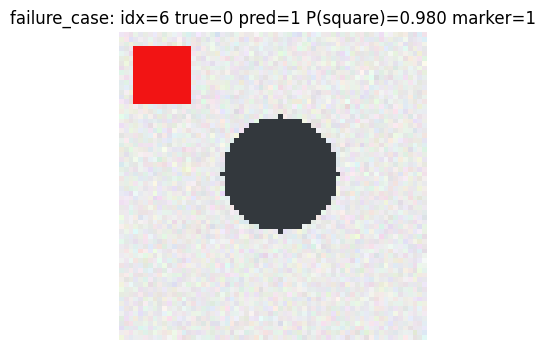

In [7]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [8]:
# Shared SHAP setup used by all ten events.
import shap

tree_explainer = shap.TreeExplainer(risk_model)
tree_shap = tree_explainer(X_test)[..., 1]  # explain P(high risk)

# GradientSHAP explains the CNN class score.
image_background = to_tensor_images(train_imgs[:24]).to(DEVICE)
image_explainer = shap.GradientExplainer(image_model, image_background)
assigned_image_indices = assigned_image_cases["image_index"].astype(int).to_numpy()
image_values = image_explainer.shap_values(
    to_tensor_images(test_imgs[assigned_image_indices]).to(DEVICE), nsamples=50
)

# Select the explanation for each case's predicted class and combine RGB channels.
assigned_image_shap = np.stack([
    np.abs(image_values[i, ..., image_pred[idx]]).sum(axis=0)
    for i, idx in enumerate(assigned_image_indices)
])

# utility function to visualize SHAP explanations for images
def show_image_shap(position, title):
    idx = assigned_image_indices[position]
    heatmap = assigned_image_shap[position]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    axes[0].imshow(test_imgs[idx])
    axes[0].set_title(f"Original image\nmarker present: {bool(test_marker[idx])}")
    axes[0].axis("off")
    image = axes[1].imshow(heatmap, cmap="magma")
    axes[1].set_title("Absolute SHAP heatmap\nbrighter = more important")
    axes[1].axis("off")
    colorbar = fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
    colorbar.set_label("|SHAP value|, RGB channels summed")
    fig.suptitle(title)
    plt.show()

# utility function to summarize SHAP explanations for specific image regions
def image_region_summary(position):
    idx = assigned_image_indices[position]
    heatmap = assigned_image_shap[position]
    shape_mask = test_imgs[idx].mean(axis=2) < 0.5
    shape_mask[3:15, 3:15] = False
    marker_mean = heatmap[3:15, 3:15].mean()
    shape_mean = heatmap[shape_mask].mean()
    return marker_mean / (shape_mean + 1e-9)

print("SHAP setup complete.")


SHAP setup complete.


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,mean_abs_SHAP
debt_ratio,0.074048
zip_proxy,0.053371
recent_late_payments,0.046016
income_k,0.028474
savings_k,0.014878
promo_seen,0.014542
loyalty_years,0.012916
app_minutes,0.006364
age,0.005935
support_tickets,0.004688


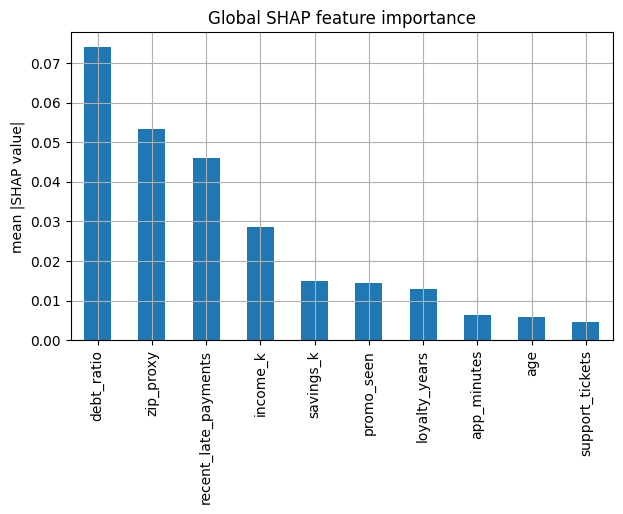

Claim: debt_ratio most strongly influences the model.
Evidence quality: Stronger global ranking relative to other features, but importance is not causal (the model may rely on spurious correlations).
Medal: Gold


In [9]:
# Output: global mean absolute SHAP importance.
global_importance = pd.Series(
    np.abs(tree_shap.values).mean(axis=0), index=feature_names
).sort_values(ascending=False)
display(global_importance.to_frame("mean_abs_SHAP"))
global_importance.plot.bar(title="Global SHAP feature importance")
plt.ylabel("mean |SHAP value|")
plt.show()

print(f"Claim: {global_importance.index[0]} most strongly influences the model.")
print("Evidence quality: Stronger global ranking relative to other features, but importance is not causal (the model may rely on spurious correlations).")
print("Medal: Gold")


## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

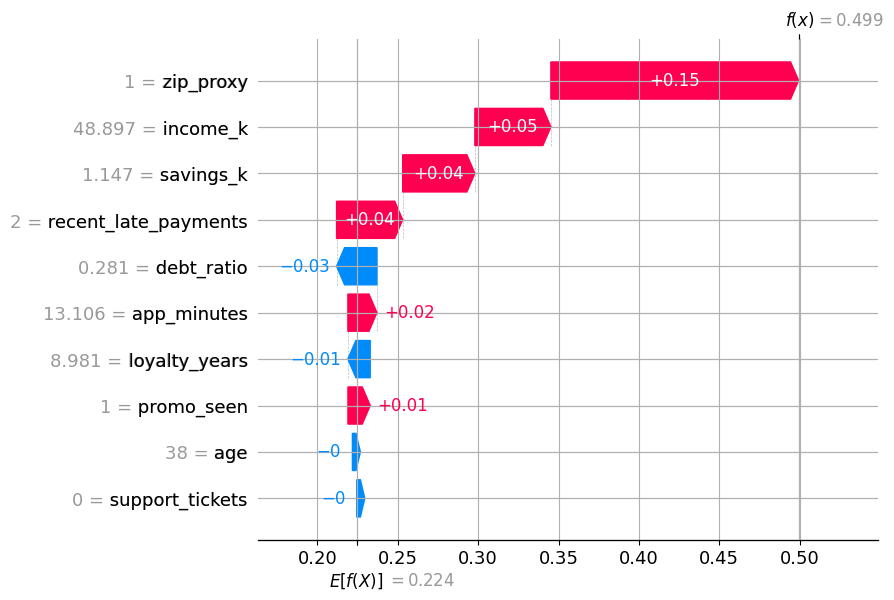

,SHAP contribution
zip_proxy,0.154128
income_k,0.047294
savings_k,0.044915
recent_late_payments,0.041122
debt_ratio,-0.025106


Claim: zip_proxy is the largest driver of this prediction.
Evidence quality: Direct row-level decomposition relative to SHAP's baseline.
Medal: Gold


In [10]:
# Output: local SHAP waterfall for the assigned row.
local_explanation = tree_shap[tabular_local_case]
shap.plots.waterfall(local_explanation, max_display=10)
top_local = pd.Series(
    local_explanation.values, index=feature_names
).sort_values(key=np.abs, ascending=False)
display(top_local.to_frame("SHAP contribution").head())

print(f"Claim: {top_local.index[0]} is the largest driver of this prediction.")
print("Evidence quality: Direct row-level decomposition relative to SHAP's baseline.")
print("Medal: Gold")


## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

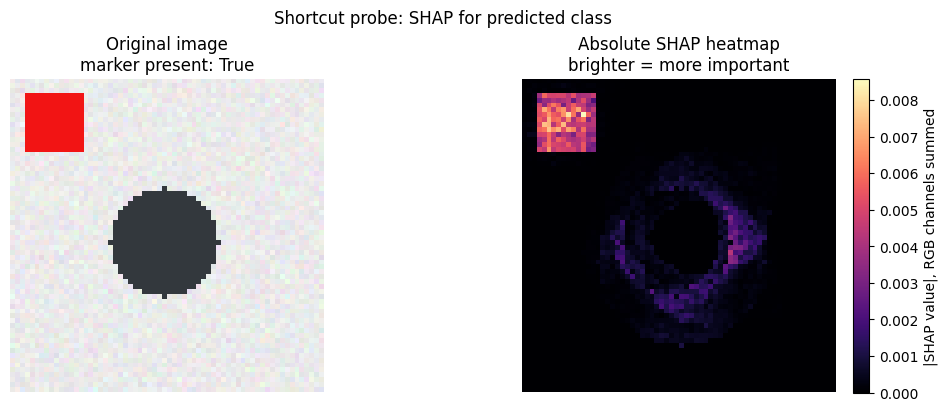

Marker attribution per pixel / shape attribution per pixel: 18.1x
Claim: The image model relies strongly on the red corner marker as a spurious shortcut.
Evidence quality: The marker dominates SHAP, but attribution alone is not a causal test. A counterfactual test by removing market would provide additional evidence.
Medal: Gold


In [11]:
# Output: GradientSHAP heatmap and marker-versus-shape attribution ratio.
show_image_shap(0, "Shortcut probe: SHAP for predicted class")
shortcut_ratio = image_region_summary(0)
print(f"Marker attribution per pixel / shape attribution per pixel: {shortcut_ratio:.1f}x")

print(f"Claim: The image model relies strongly on the red corner marker as a spurious shortcut.")
print("Evidence quality: The marker dominates SHAP, but attribution alone is not a causal test. A counterfactual test by removing market would provide additional evidence.")
print("Medal: Gold")


## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

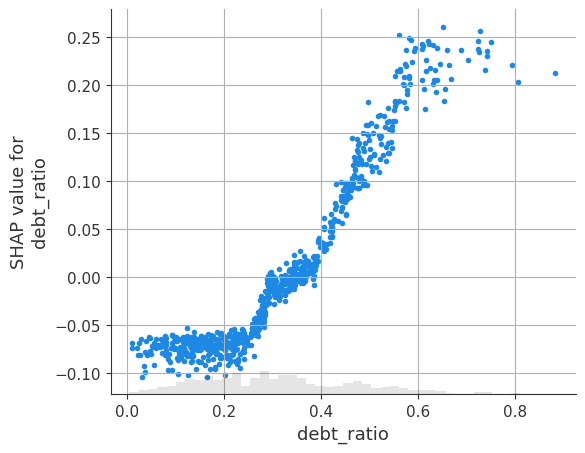

Claim: Higher debt_ratio generally increases the model's predicted risk. However, after 0.6, the effect plateaus.
Evidence quality: Strong global model-effect evidence, but it is not causal. The plateau after 0.6 suggests diminishing returns, which could be further investigated.
Medal: Gold


In [12]:
# Output: SHAP dependence plot for debt ratio.
shap.plots.scatter(tree_shap[:, "debt_ratio"])

print("Claim: Higher debt_ratio generally increases the model's predicted risk. However, after 0.6, the effect plateaus.")
print("Evidence quality: Strong global model-effect evidence, but it is not causal. The plateau after 0.6 suggests diminishing returns, which could be further investigated.")
print("Medal: Gold")


## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

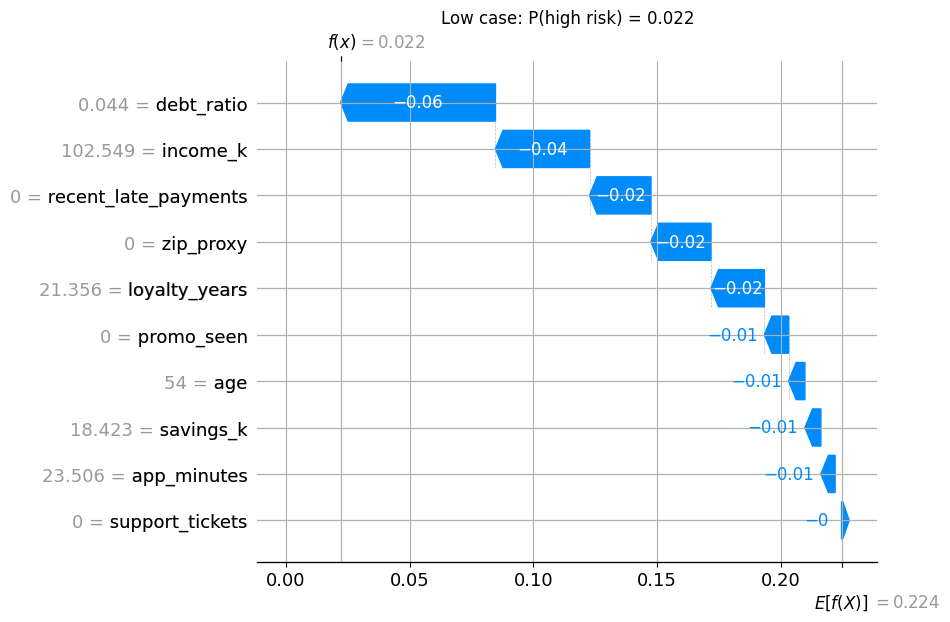

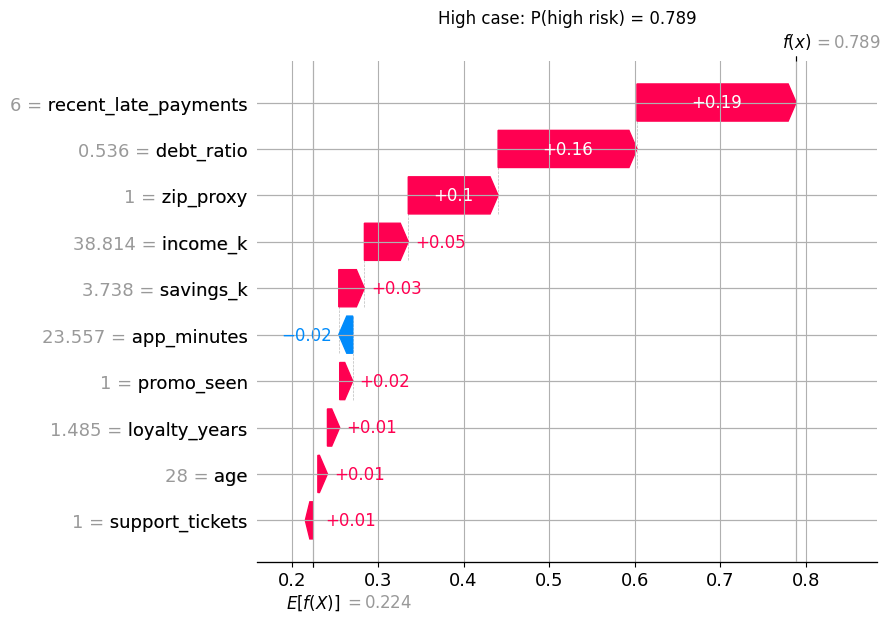

,high minus low SHAP
debt_ratio,0.224721
recent_late_payments,0.210798
zip_proxy,0.129189
income_k,0.089254
savings_k,0.036359
loyalty_years,0.035884
promo_seen,0.025015
age,0.017802
app_minutes,-0.010558
support_tickets,0.007922


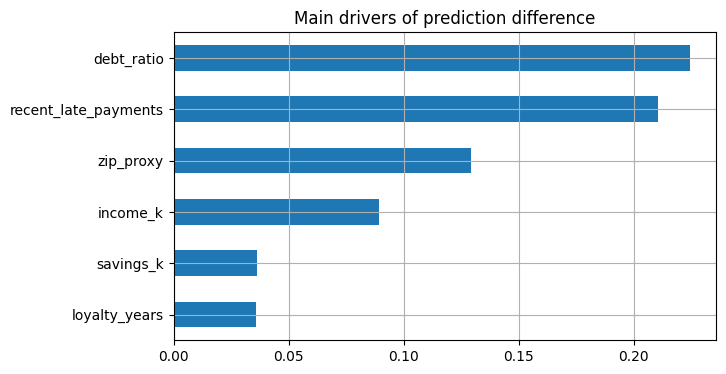

Claim: Debt ratio, late payments, and zip_proxy explain most of the gap.
Evidence quality: Direct contrast using the same SHAP baseline.
Medal: Gold


In [13]:
# Output 1: SHAP explanation for the low-risk case.
shap.plots.waterfall(tree_shap[tabular_low_case], max_display=10, show=False)
plt.title(f"Low case: P(high risk) = {tabular_proba[tabular_low_case]:.3f}")
plt.show()

# Output 2: SHAP explanation for the high-risk case.
shap.plots.waterfall(tree_shap[tabular_high_case], max_display=10, show=False)
plt.title(f"High case: P(high risk) = {tabular_proba[tabular_high_case]:.3f}")
plt.show()

# Output 3: difference between their SHAP contributions.
shap_difference = pd.Series(
    tree_shap.values[tabular_high_case] - tree_shap.values[tabular_low_case],
    index=feature_names,
).sort_values(key=np.abs, ascending=False)
display(shap_difference.to_frame("high minus low SHAP"))
shap_difference.head(6).sort_values().plot.barh(title="Main drivers of prediction difference")
plt.show()

print("Claim: Debt ratio, late payments, and zip_proxy explain most of the gap.")
print("Evidence quality: Direct contrast using the same SHAP baseline.")
print("Medal: Gold")


## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,feature_1,feature_2,mean_abs_interaction
18,debt_ratio,recent_late_payments,0.005554
15,income_k,zip_proxy,0.004603
22,debt_ratio,zip_proxy,0.003969
33,recent_late_payments,zip_proxy,0.003779
40,app_minutes,zip_proxy,0.003288
9,income_k,debt_ratio,0.002769
19,debt_ratio,savings_k,0.002645
17,debt_ratio,loyalty_years,0.002556
11,income_k,recent_late_payments,0.002465
23,debt_ratio,promo_seen,0.002392


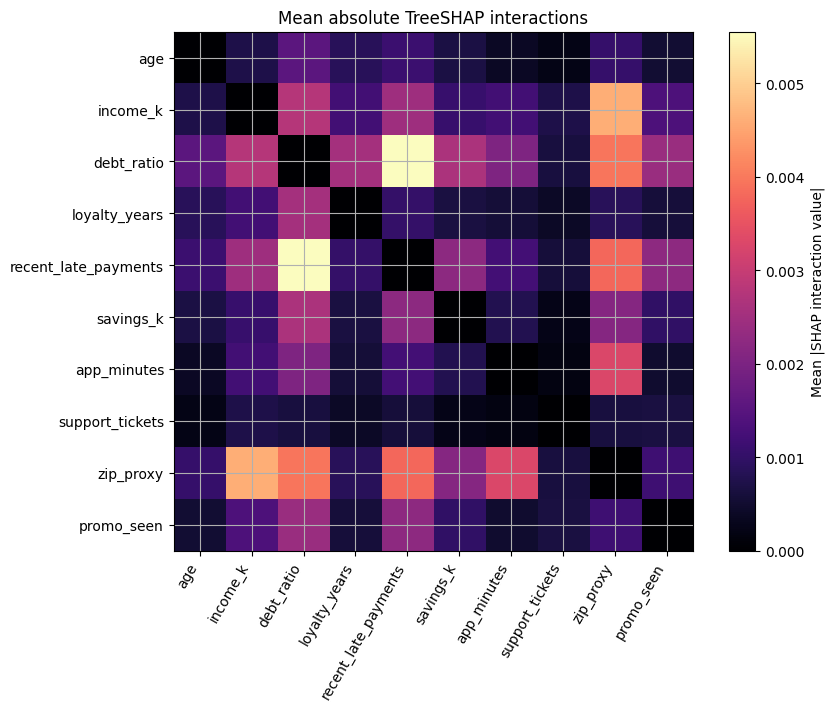

Claim: debt_ratio and recent_late_payments have the strongest interaction; But zip_proxy have many interaction effects as well.
Evidence quality: Direct tree interaction measure; predictive, not causal.
Medal: Gold


In [14]:
# Output: strongest pairwise TreeSHAP interactions.
interaction_values = np.asarray(
    tree_explainer.shap_interaction_values(X_test.iloc[:300])
)[..., 1]
mean_interaction = np.abs(interaction_values).mean(axis=0)
np.fill_diagonal(mean_interaction, 0)
interaction_rows = [
    (feature_names[i], feature_names[j], mean_interaction[i, j])
    for i in range(len(feature_names)) for j in range(i + 1, len(feature_names))
]
interaction_table = pd.DataFrame(
    interaction_rows, columns=["feature_1", "feature_2", "mean_abs_interaction"]
).sort_values("mean_abs_interaction", ascending=False)
display(interaction_table.head(10))

# Heatmap of all pairwise interaction strengths.
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
heatmap = ax.imshow(mean_interaction, cmap="magma")
ax.set_xticks(range(len(feature_names)), labels=feature_names, rotation=60, ha="right")
ax.set_yticks(range(len(feature_names)), labels=feature_names)
ax.set_title("Mean absolute TreeSHAP interactions")
colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Mean |SHAP interaction value|")
plt.show()

best_pair = interaction_table.iloc[0]
print(f"Claim: {best_pair.feature_1} and {best_pair.feature_2} have the strongest interaction; But zip_proxy have many interaction effects as well.")
print("Evidence quality: Direct tree interaction measure; predictive, not causal.")
print("Medal: Gold")


## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

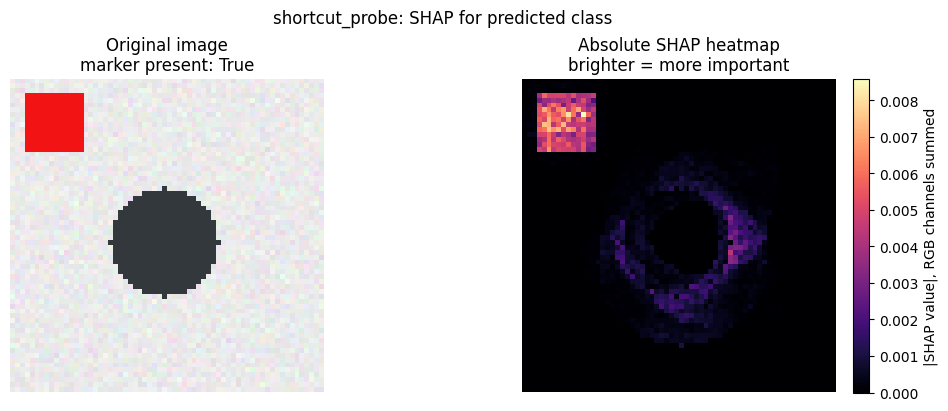

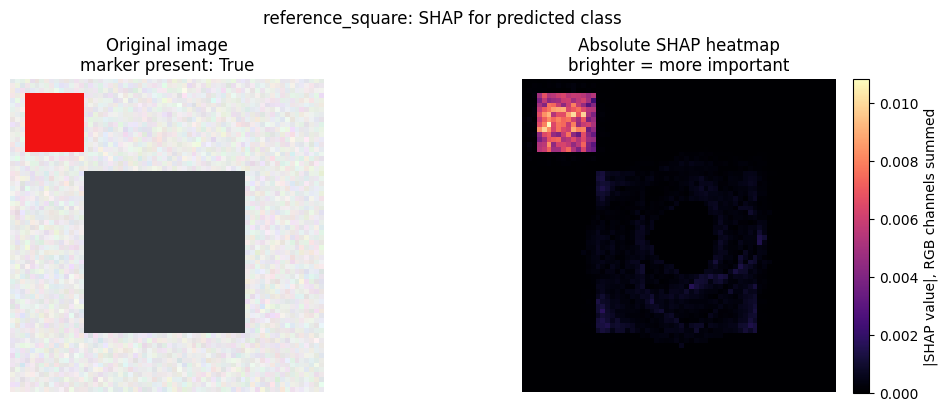

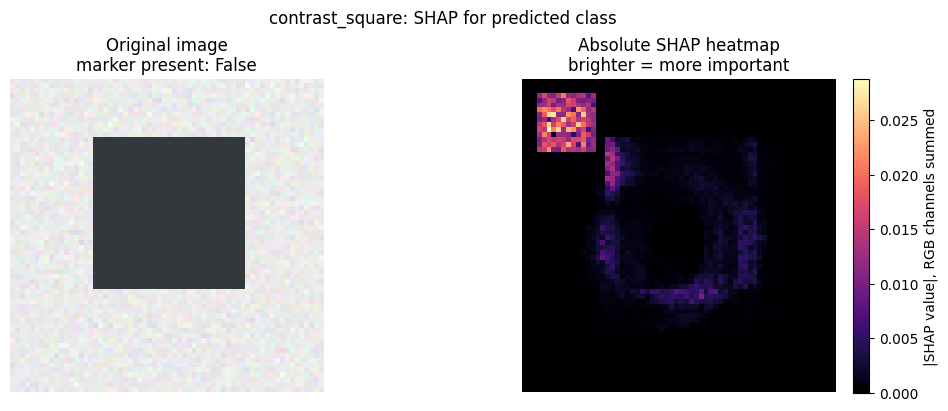

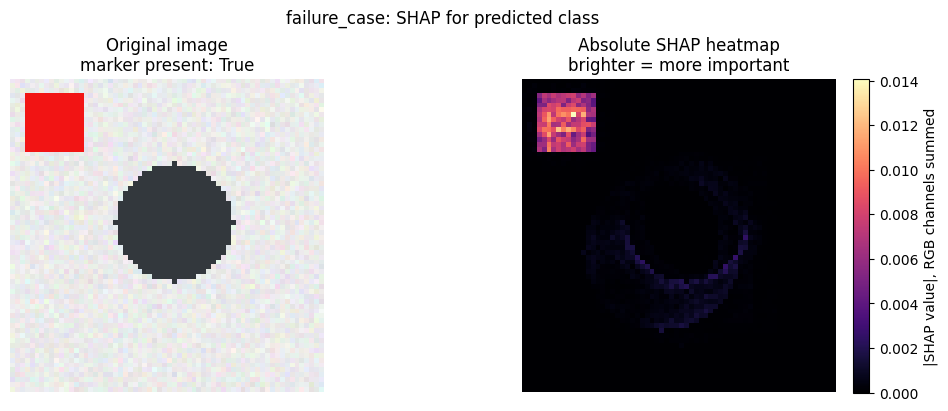

,marker_to_shape_attribution_per_pixel
case_name,
shortcut_probe,18.061968
reference_square,17.792938
contrast_square,8.963850
failure_case,50.970579


Claim: The corner marker (shortcut) is the main image region driving these predictions.
Evidence quality: Direct spatial attribution across four cases; background-sensitive.
Medal: Gold


In [15]:
# Output: predicted-class GradientSHAP maps for all assigned images.
for position, name in enumerate(assigned_image_cases["case_name"]):
    show_image_shap(position, f"{name}: SHAP for predicted class")
region_ratios = pd.Series(
    [image_region_summary(i) for i in range(len(assigned_image_indices))],
    index=assigned_image_cases["case_name"],
    name="marker_to_shape_attribution_per_pixel",
)
display(region_ratios.to_frame())

print("Claim: The corner marker (shortcut) is the main image region driving these predictions.")
print("Evidence quality: Direct spatial attribution across four cases; background-sensitive.")
print("Medal: Gold")


## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

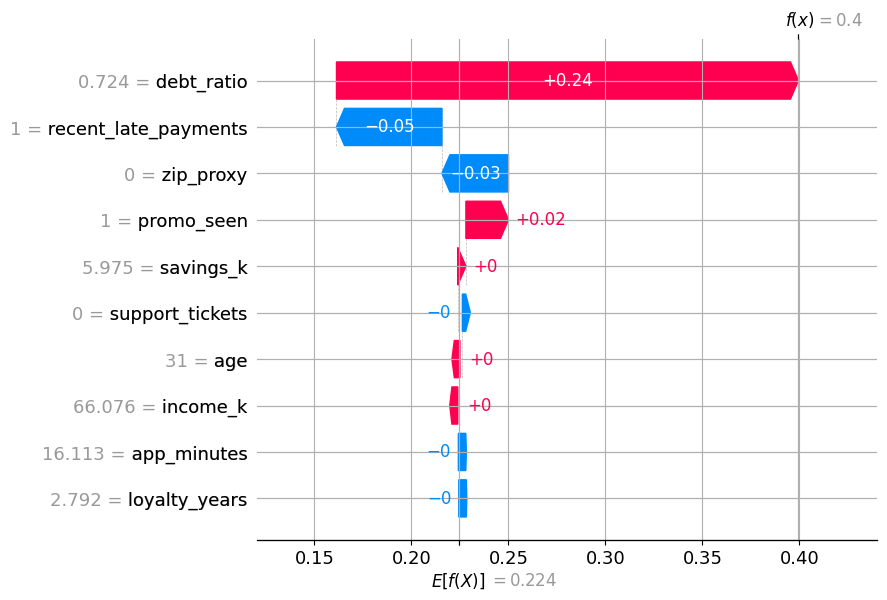

,SHAP contribution
debt_ratio,0.238117
recent_late_payments,-0.054353
zip_proxy,-0.034309
promo_seen,0.021951
savings_k,0.004233


Claim: Debt raised risk, but no late payments and zip_proxy=0 helped keep the score below 0.5.
Evidence quality: Explains the specific wrong score, but not the full cause of generalization failure.
Medal: Silver


In [16]:
# Output: local SHAP explanation for the incorrect tabular prediction.
failure_explanation = tree_shap[tabular_failure_case]
shap.plots.waterfall(failure_explanation, max_display=10)
failure_drivers = pd.Series(
    failure_explanation.values, index=feature_names
).sort_values(key=np.abs, ascending=False)
display(failure_drivers.to_frame("SHAP contribution").head())

print("Claim: Debt raised risk, but no late payments and zip_proxy=0 helped keep the score below 0.5.")
print("Evidence quality: Explains the specific wrong score, but not the full cause of generalization failure.")
print("Medal: Silver")


## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [17]:
# Output: prediction and SHAP stability under tiny perturbations.
case = X_test.iloc[[tabular_local_case]]
noise = np.random.default_rng(SEED).normal(
    0, 0.01 * X_train.std().to_numpy(), size=(30, len(feature_names))
)
perturbed = pd.DataFrame(case.to_numpy() + noise, columns=feature_names)
perturbed = perturbed.clip(X_train.min(), X_train.max(), axis=1)
perturbed_prob = predict_risk_proba(perturbed)[:, 1]
perturbed_shap = tree_explainer(perturbed)[..., 1].values
stability = pd.Series({
    "minimum probability": perturbed_prob.min(),
    "maximum probability": perturbed_prob.max(),
    "probability std. dev.": perturbed_prob.std(),
    "mean absolute SHAP change": np.abs(perturbed_shap - tree_shap.values[tabular_local_case]).mean(),
})
display(stability.to_frame("value"))

print("Claim: Do not trust the hard class label; this case is at the boundary and can flip (49% to 51% with threshold of 0.5).")
print("Evidence quality: Useful local robustness evidence, but not a full trust assessment.")
print("Medal: Silver")


,value
minimum probability,0.496725
maximum probability,0.507224
probability std. dev.,0.002645
mean absolute SHAP change,0.000506


Claim: Do not trust the hard class label; this case is at the boundary and can flip (49% to 51% with threshold of 0.5).
Evidence quality: Useful local robustness evidence, but not a full trust assessment.
Medal: Silver


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [18]:
# Output: compact strategy profile from the earlier SHAP results.
strategy_summary = pd.DataFrame({
    "tabular_top_feature": global_importance.index[:4],
    "tabular_mean_abs_SHAP": global_importance.iloc[:4].round(3).to_numpy(),
    "image_case": assigned_image_cases["case_name"],
    "marker_vs_shape_attribution": region_ratios.round(1).to_numpy(),
})
display(strategy_summary)

print("Claim: The tabular model mainly uses debt, late payments, income, and zip proxy;")
print("       the image model relies heavily on the corner marker rather than only shape.")
print("Evidence quality: Consistent multi-case evidence, but image coverage is still small.")
print("Medal: Silver")


,tabular_top_feature,tabular_mean_abs_SHAP,image_case,marker_vs_shape_attribution
0,debt_ratio,0.074,shortcut_probe,18.1
1,zip_proxy,0.053,reference_square,17.8
2,recent_late_payments,0.046,contrast_square,9.0
3,income_k,0.028,failure_case,51.0


Claim: The tabular model mainly uses debt, late payments, income, and zip proxy;
       the image model relies heavily on the corner marker rather than only shape.
Evidence quality: Consistent multi-case evidence, but image coverage is still small.
Medal: Silver


# Final Model Profile

**Tabular model strategy:**
Which features seem important? Did you find global effects, local effects, interactions, or suspicious proxies? What can your method support?

The model relies most on `debt_ratio`, followed by `zip_proxy`, `recent_late_payments`, and `income_k`. Higher debt generally raises predicted risk, and the strongest detected interaction is between debt ratio and recent late payments. The importance of `zip_proxy` is suspicious because it may let the model use a proxy rather than only financially meaningful evidence and have many interactions with other features (as shown by heatmap above). TreeSHAP supports these global, local, and interaction claims, but it does not make them causal.

**Image model strategy:**
Does the classifier appear to use the shape, the red marker, or both? What evidence supports that claim?

The classifier appears to rely heavily on the red corner marker rather than learning only the intended shape. In the shortcut case, average SHAP attribution per marker pixel was about 18 times the attribution per shape pixel, and the marker region was prominent across the assigned cases as shown in visuals above. This is strong evidence of shortcut use, although a controlled marker-removal experiment (counterfactual) would provide a more direct causal test.

**Your method's decathlon profile:**  
Where did your method perform well? Where did it fail? What kind of explanation question is it best suited for?

SHAP performed best for global feature importance, individual predictions, prediction comparisons, feature effects, and tree interactions. GradientSHAP also localized important image regions. It was less conclusive for proving shortcut causality, explaining why the model learned a failure, and deciding whether a human should trust a prediction. Those questions need interventions, performance and calibration evidence, or domain judgment in addition to attribution as well as using other methods like counterfactuals.

**Open questions:**  
What would you want to compare with classmates who used other methods?

I would compare these results with ALE or PDP for global effects, Grad-CAM for image localization, and counterfactual marker removal for shortcut confirmation. I would also check whether LIME produces similar local explanations and whether its results are as stable as SHAP's.
